<a href="https://colab.research.google.com/github/Monisha1205/google_colab_quanqual/blob/main/Normal_distribution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Placement.csv to Placement.csv


In [3]:
dataset=pd.read_csv("/content/Placement.csv")
dataset

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,214,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


In [4]:
!pip install seaborn

In [5]:
import seaborn as sns

In [9]:
dataset["salary"][dataset["status"] == "Not Placed"]  = 0

/tmp/ipykernel_1239/124606807.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dataset["salary"][dataset["status"] == "Not Placed"]  = 0
/tmp/ipykernel_1239/124606807.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of

In [10]:
dataset["salary"][dataset["status"] == "Not Placed"]

,salary
3,0.0
5,0.0
6,0.0
9,0.0
12,0.0
...,...
198,0.0
201,0.0
206,0.0
208,0.0


In [14]:
dataset.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,0.0
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [15]:
def quanqual(dataset):
  quan = []
  qual = []
  for ch in  dataset.columns:
    if dataset[ch].dtype == "O":
      #print("qual")
      qual.append(ch)
    else:
      #print("quan")
      quan.append(ch)
  return quan,qual
quan,qual = quanqual(dataset)

In [16]:
quan

['sl_no', 'ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary']

In [17]:
qual

['gender',
 'ssc_b',
 'hsc_b',
 'hsc_s',
 'degree_t',
 'workex',
 'specialisation',
 'status']

In [18]:
descriptive = pd.DataFrame(index = ["Mean", "Median", "Mode", "Min", "25th", "50th", "75th", "Max", "IQR", "1.5IQR", "LowerOutlier", "GreaterOutlier"], columns = quan)
for ColumnsName in quan:
  descriptive[ColumnsName]["Mean"] = dataset[ColumnsName].mean()
  descriptive[ColumnsName]["Median"] = dataset[ColumnsName].median()
  descriptive[ColumnsName]["Mode"] = dataset[ColumnsName].mode()[0]
  descriptive[ColumnsName]["Min"] = dataset.describe()[ColumnsName]["min"]
  descriptive[ColumnsName]["25th"] = dataset.describe()[ColumnsName]["25%"]
  descriptive[ColumnsName]["50th"] = dataset.describe()[ColumnsName]["50%"]
  descriptive[ColumnsName]["75th"] = dataset.describe()[ColumnsName]["75%"]
  descriptive[ColumnsName]["Max"] = dataset.describe()[ColumnsName]["max"]
  descriptive[ColumnsName]["IQR"] = descriptive[ColumnsName]["75th"] - descriptive[ColumnsName]["25th"]
  descriptive[ColumnsName]["1.5IQR"] = 1.5 * descriptive[ColumnsName]["IQR"]
  descriptive[ColumnsName]["LowerOutlier"] = descriptive[ColumnsName]["25th"] - descriptive[ColumnsName]["1.5IQR"]
  descriptive[ColumnsName]["GreaterOutlier"] = descriptive[ColumnsName]["75th"] + descriptive[ColumnsName]["1.5IQR"]

/tmp/ipykernel_1239/3316622404.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  descriptive[ColumnsName]["Mean"] = dataset[ColumnsName].mean()
/tmp/ipykernel_1239/3316622404.py:4: FutureWarning: ChainedAssignmentError: behaviour will chan

In [19]:
descriptive

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
Mean,108.0,67.303395,66.333163,66.370186,72.100558,62.278186,198702.325581
Median,108.0,67.0,65.0,66.0,71.0,62.0,240000.0
Mode,1,62.0,63.0,65.0,60.0,56.7,0.0
Min,1.0,40.89,37.0,50.0,50.0,51.21,0.0
25th,54.5,60.6,60.9,61.0,60.0,57.945,0.0
50th,108.0,67.0,65.0,66.0,71.0,62.0,240000.0
75th,161.5,75.7,73.0,72.0,83.5,66.255,282500.0
Max,215.0,89.4,97.7,91.0,98.0,77.89,940000.0
IQR,107.0,15.1,12.1,11.0,23.5,8.31,282500.0
1.5IQR,160.5,22.65,18.15,16.5,35.25,12.465,423750.0


In [20]:
lesser = []
greater = []
for ColumnsNames in quan:
  if descriptive[ColumnsNames]["Min"] < descriptive[ColumnsNames]["LowerOutlier"]:
    lesser.append(ColumnsNames)
  if descriptive[ColumnsNames]["Max"] > descriptive[ColumnsNames]["GreaterOutlier"]:
    greater.append(ColumnsNames)


In [21]:
lesser

['hsc_p']

In [22]:
greater

['hsc_p', 'degree_p', 'salary']

In [31]:
for LesserColumnes in lesser:
  dataset[LesserColumnes][dataset[LesserColumnes] < descriptive[LesserColumnes]["LowerOutlier"]] = descriptive[LesserColumnes]["LowerOutlier"]
for GreaterColumnes in greater:
  dataset[GreaterColumnes][dataset[GreaterColumnes] > descriptive[GreaterColumnes]["GreaterOutlier"]] = descriptive[GreaterColumnes]["GreaterOutlier"]

/tmp/ipykernel_1239/2650692933.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dataset[LesserColumnes][dataset[LesserColumnes] < descriptive[LesserColumnes]["LowerOutlier"]] = descriptive[LesserColumnes]["LowerOutlier"]
/tmp/ipykernel_12

In [32]:
new_dataset = dataset

In [33]:
descriptive = pd.DataFrame(index = ["Mean", "Median", "Mode", "Min", "25th", "50th", "75th", "Max", "IQR", "1.5IQR", "LowerOutlier", "GreaterOutlier"], columns = quan)
for ColumnsName in quan:
  descriptive[ColumnsName]["Mean"] = new_dataset[ColumnsName].mean()
  descriptive[ColumnsName]["Median"] = new_dataset[ColumnsName].median()
  descriptive[ColumnsName]["Mode"] = new_dataset[ColumnsName].mode()[0]
  descriptive[ColumnsName]["Min"] = new_dataset.describe()[ColumnsName]["min"]
  descriptive[ColumnsName]["25th"] = new_dataset.describe()[ColumnsName]["25%"]
  descriptive[ColumnsName]["50th"] = new_dataset.describe()[ColumnsName]["50%"]
  descriptive[ColumnsName]["75th"] = new_dataset.describe()[ColumnsName]["75%"]
  descriptive[ColumnsName]["Max"] = new_dataset.describe()[ColumnsName]["max"]
  descriptive[ColumnsName]["IQR"] = descriptive[ColumnsName]["75th"] - descriptive[ColumnsName]["25th"]
  descriptive[ColumnsName]["1.5IQR"] = 1.5 * descriptive[ColumnsName]["IQR"]
  descriptive[ColumnsName]["LowerOutlier"] = descriptive[ColumnsName]["25th"] - descriptive[ColumnsName]["1.5IQR"]
  descriptive[ColumnsName]["GreaterOutlier"] = descriptive[ColumnsName]["75th"] + descriptive[ColumnsName]["1.5IQR"]

/tmp/ipykernel_1239/1527319527.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  descriptive[ColumnsName]["Mean"] = new_dataset[ColumnsName].mean()
/tmp/ipykernel_1239/1527319527.py:4: FutureWarning: ChainedAssignmentError: behaviour will 

In [34]:
descriptive

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
Mean,108.0,67.303395,66.334744,66.358558,72.100558,62.278186,197615.116279
Median,108.0,67.0,65.0,66.0,71.0,62.0,240000.0
Mode,1,62.0,63.0,65.0,60.0,56.7,0.0
Min,1.0,40.89,42.75,50.0,50.0,51.21,0.0
25th,54.5,60.6,60.9,61.0,60.0,57.945,0.0
50th,108.0,67.0,65.0,66.0,71.0,62.0,240000.0
75th,161.5,75.7,73.0,72.0,83.5,66.255,282500.0
Max,215.0,89.4,91.15,88.5,98.0,77.89,706250.0
IQR,107.0,15.1,12.1,11.0,23.5,8.31,282500.0
1.5IQR,160.5,22.65,18.15,16.5,35.25,12.465,423750.0


In [35]:
lesser = []
greater = []
for ColumnsNames in quan:
  if descriptive[ColumnsNames]["Min"] < descriptive[ColumnsNames]["LowerOutlier"]:
    lesser.append(ColumnsNames)
  if descriptive[ColumnsNames]["Max"] > descriptive[ColumnsNames]["GreaterOutlier"]:
    greater.append(ColumnsNames)

In [36]:
lesser

[]

In [37]:
greater

[]

In [38]:
new_dataset.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,0.0
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [47]:
dataset = new_dataset

In [48]:
dataset

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,0.0
4,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


/tmp/ipykernel_1239/40979546.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['ssc_p'])


<Axes: xlabel='ssc_p', ylabel='Density'>

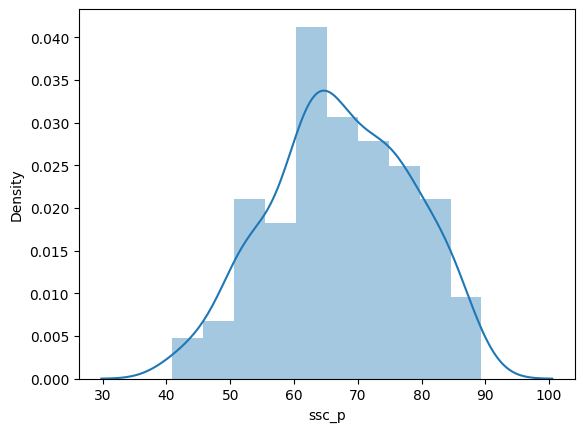

In [50]:
sns.distplot(dataset['ssc_p'])

In [51]:
quan

['sl_no', 'ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary']

/tmp/ipykernel_1239/1108154586.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['hsc_p'])


<Axes: xlabel='hsc_p', ylabel='Density'>

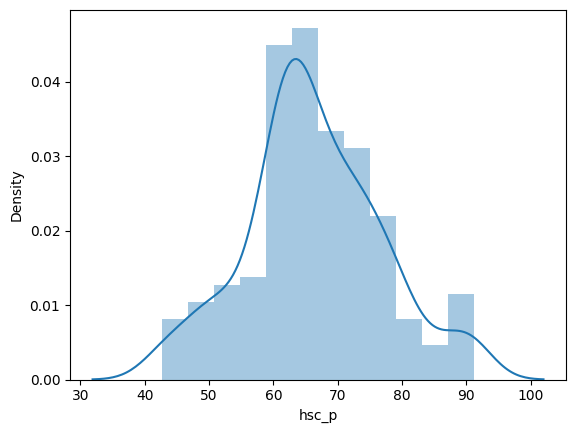

In [52]:
sns.distplot(dataset['hsc_p'])

/tmp/ipykernel_1239/492941456.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['salary'])


<Axes: xlabel='salary', ylabel='Density'>

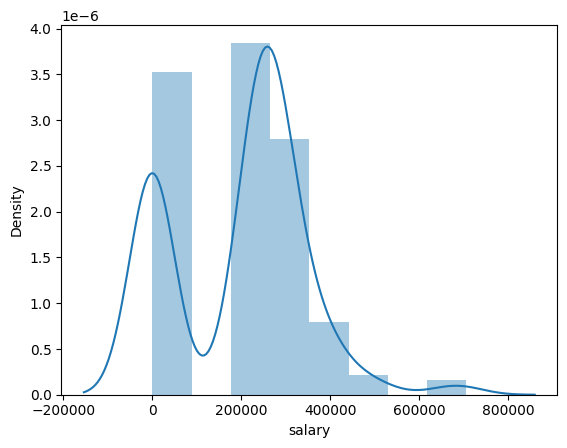

In [53]:
sns.distplot(dataset['salary'])